# 03 — Feature Engineering (Weekly Version)
## From EDA Insights to Model-Ready Features at Weekly Granularity

**Why weekly?** Daily forecasting on sparse retail data hit a noise floor (64% of
daily values are 0 or 1, integer-rounding noise dominates). Restaurants make
inventory and staffing decisions weekly, not daily. Aggregating to weekly:
- Reduces noise dramatically (CV drops from 0.6-1.5 to 0.3-0.7 per item)
- Aligns the model output with real business decision frequency
- Improves all metrics meaningfully (predicted WAPE 0.40 vs daily 0.73)

The daily anomaly detection module (Module 4) keeps daily granularity — different
problem, different optimal time scale.

**Input:** `weekly_item_demand.csv` (from notebook 01's weekly aggregation)

**Output:** `forecasting_features_weekly.csv` — ready for Prophet, SARIMA, XGBoost,
LightGBM, LSTM, TFT.

---

### EDA Finding → Feature Mapping (adapted to weekly)

| EDA Finding (daily-level) | Weekly Feature |
|---|---|
| Weekly seasonality (Sat/Mon 1.5×) | Aggregated away (within-week pattern) |
| Monthly seasonality (~30% swing) | `month` sin/cos encoding |
| Long-term growth (+15% / 18mo) | `weeks_since_start` |
| Ramadan suppression (-66% Cafe) | `is_ramadan_week` + `is_ramadan_week × section` |
| Holiday spikes (desserts 6×) | `n_holidays_in_week` + `holiday × category` |
| Item seasonality (summer/winter) | `month × section` interaction |
| Lag-7 daily autocorrelation (0.49) | Becomes `lag_1_week` (same role) |
| Cross-item learning gap (post-04c) | `total_lag_1`, `section_lag_1`, `section_rolling_4`, `item_share_of_section` |
| Price signal | `avg_price` (already present) |

**Note:** day-of-week, section × day-of-week, and lag_1/lag_2/lag_3 features
disappear at weekly granularity (aggregated away). Their predictive content
gets absorbed into the weekly aggregate's natural variability.

---

## 1. Setup and data loading

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings
warnings.filterwarnings('ignore')

# === ADJUST THIS PATH TO YOUR FOLDER LAYOUT ===
DATASETS_DIR = '../../datasets'

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['font.size'] = 10

print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\slimc\Desktop\Notebooks\Module 2\Feature_Engineering


In [2]:
# Load weekly demand from notebook 01
df = pd.read_csv(os.path.join(DATASETS_DIR, 'weekly_item_demand.csv'), parse_dates=['week_start'])
df = df.sort_values(['item_name', 'week_start']).reset_index(drop=True)

print(f"Loaded: {len(df):,} rows")
print(f"Date range: {df['week_start'].min().date()} → {df['week_start'].max().date()}")
print(f"Weeks: {df['week_start'].nunique()}")
print(f"Items: {df['item_name'].nunique()}")
print(f"Sections: {sorted(df['section'].unique())}")
print(f"Columns: {list(df.columns)}")
print(f"\nSplit distribution:")
print(df.groupby('split').agg(weeks=('week_start','nunique'), rows=('quantity','count')))
print(f"\nQuantity stats:")
print(df['quantity'].describe().round(2))

Loaded: 19,032 rows
Date range: 2023-01-03 → 2025-12-23
Weeks: 156
Items: 122
Sections: ['American', 'Cafe', 'Healthy_Vegan', 'Italian', 'Japanese', 'Mexican', 'Steakhouse']
Columns: ['week_start', 'item_name', 'quantity', 'section', 'category', 'avg_price', 'item_id', 'split']

Split distribution:
       weeks   rows
split              
test      39   4758
train    104  12688
val       13   1586

Quantity stats:
count    19032.00
mean         9.20
std          5.71
min          0.00
25%          5.00
50%          8.00
75%         12.00
max         43.00
Name: quantity, dtype: float64


## 2. Calendar features (weekly-level)

**EDA justification:**
- Monthly seasonality shows ~30% annual swing (Feb-Apr trough, July peak, Dec spike)
- Long-term growth needs a linear trend feature
- Day-of-week is gone (aggregated away), but week-of-year carries seasonality

We use cyclical sin/cos for month and week-of-year because they preserve the
circular nature (December close to January, week 52 close to week 1).

In [3]:
# ── Time-based features extracted from week_start (which is always Monday) ──

# Month — primary seasonality signal at weekly level
df['month'] = df['week_start'].dt.month
df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)

# Quarter — coarser seasonality
df['quarter'] = df['week_start'].dt.quarter

# Week of year (1-52)
df['week_of_year'] = df['week_start'].dt.isocalendar().week.astype(int)
df['woy_sin'] = np.sin(2 * np.pi * df['week_of_year'] / 52)
df['woy_cos'] = np.cos(2 * np.pi * df['week_of_year'] / 52)

# Long-term trend — weeks since dataset start
start_date = df['week_start'].min()
df['weeks_since_start'] = ((df['week_start'] - start_date).dt.days // 7).astype(int)

# Year (helps the model distinguish 2023 from 2024)
df['year'] = df['week_start'].dt.year

print("Calendar features added:")
print(f"  month, month_sin, month_cos")
print(f"  quarter")
print(f"  week_of_year, woy_sin, woy_cos")
print(f"  weeks_since_start (linear trend)")
print(f"  year")
print(f"\nSample (first item, first 5 weeks):")
df[['week_start', 'item_name', 'month', 'week_of_year', 'weeks_since_start']].head()

Calendar features added:
  month, month_sin, month_cos
  quarter
  week_of_year, woy_sin, woy_cos
  weeks_since_start (linear trend)
  year

Sample (first item, first 5 weeks):


,week_start,item_name,month,week_of_year,weeks_since_start
0,2023-01-03,14oz Ribeye,1,1,0
1,2023-01-10,14oz Ribeye,1,2,1
2,2023-01-17,14oz Ribeye,1,3,2
3,2023-01-24,14oz Ribeye,1,4,3
4,2023-01-31,14oz Ribeye,1,5,4


## 3. Ramadan features

**EDA justification:**
- Ramadan crashes overall demand to ~100 items/day (was ~160-200 baseline)
- Impact is **bidirectional and uneven**:
  - Cafe -70%, Healthy_Vegan -64% (daytime/light consumption disappears during fasting)
  - Steakhouse +15%, Mexican +10% (heavy/protein-rich food benefits from iftar evening meals)
- A flat `is_ramadan` flag would average these out and predict a meaningless mid-range decline
- Need: `is_ramadan_week` + **mandatory** `ramadan × section` interaction

A week is "Ramadan" if 4+ days of it fall within Ramadan dates. This handles
edge weeks where Ramadan starts mid-week without being binary-misclassified.

Ramadan dates in the dataset range:
- **2023:** March 22 → April 20 (30 days)
- **2024:** March 11 → April 9 (30 days)
- **2025:** February 28 → March 29 (30 days)


In [4]:
# ── Helper: count Ramadan days within each week ──
ramadan_periods = [
    (pd.Timestamp('2023-03-22'), pd.Timestamp('2023-04-20')),
    (pd.Timestamp('2024-03-11'), pd.Timestamp('2024-04-09')),
    (pd.Timestamp('2025-02-28'), pd.Timestamp('2025-03-29')),
]

def ramadan_days_in_week(week_start):
    """Count how many days of the week (Mon-Sun) fall within Ramadan."""
    week_end = week_start + pd.Timedelta(days=6)
    total_days = 0
    for r_start, r_end in ramadan_periods:
        overlap_start = max(week_start, r_start)
        overlap_end = min(week_end, r_end)
        if overlap_start <= overlap_end:
            total_days += (overlap_end - overlap_start).days + 1
    return total_days

df['ramadan_days_in_week'] = df['week_start'].apply(ramadan_days_in_week)

# Binary flag: a week is "Ramadan" if 4+ days of it are within Ramadan
df['is_ramadan_week'] = (df['ramadan_days_in_week'] >= 4).astype(int)

# Pre/post Ramadan windows (1 week before, 1 week after)
def ramadan_status(week_start):
    week_end = week_start + pd.Timedelta(days=6)
    for r_start, r_end in ramadan_periods:
        # Week is BEFORE Ramadan starts (within 7 days)
        days_to_start = (r_start - week_end).days
        if 0 < days_to_start <= 7:
            return 'pre'
        # Week is AFTER Ramadan ends (within 7 days)
        days_after_end = (week_start - r_end).days
        if 0 < days_after_end <= 7:
            return 'post'
    return 'none'

ram_status = df['week_start'].apply(ramadan_status)
df['is_pre_ramadan'] = (ram_status == 'pre').astype(int)
df['is_post_ramadan'] = (ram_status == 'post').astype(int)

# Ramadan × section interaction — captures bidirectional impact
# (Cafe/Healthy_Vegan crash, Steakhouse/Mexican gain)
sections = sorted(df['section'].unique())
for sec in sections:
    col = f'ramadan_x_{sec.lower().replace("_", "")}'
    df[col] = df['is_ramadan_week'] * (df['section'] == sec).astype(int)

n_ramadan_weeks = df['is_ramadan_week'].sum() // df['item_name'].nunique()
print(f"Ramadan weeks flagged: {n_ramadan_weeks} weeks")
print(f"Pre-Ramadan rows: {df['is_pre_ramadan'].sum():,}")
print(f"Post-Ramadan rows: {df['is_post_ramadan'].sum():,}")
print(f"Ramadan × section interactions: {len(sections)} columns")
print(f"\nMean weekly demand during Ramadan by section:")
ram = df[df['is_ramadan_week'] == 1].groupby('section')['quantity'].mean()
noram = df[df['is_ramadan_week'] == 0].groupby('section')['quantity'].mean()
impact = ((ram / noram - 1) * 100).round(1)
print(impact.to_string())


Ramadan weeks flagged: 13 weeks
Pre-Ramadan rows: 366
Post-Ramadan rows: 366
Ramadan × section interactions: 7 columns

Mean weekly demand during Ramadan by section:
section
American        -30.4
Cafe            -63.1
Healthy_Vegan   -62.2
Italian         -33.1
Japanese        -26.1
Mexican         -23.8
Steakhouse      -25.0


## 4. Holiday features

**EDA justification:**
- NYE 2023 showed 2-6× lift; desserts spike harder than mains (6× vs 3.5×)
- December is highest month (5,860 vs July 5,593)
- Need: count of holidays in week + holiday × category interaction

At weekly level, the question changes from "is today a holiday?" to "how many
holiday days does this week contain?"  A week with 2 holiday days will see a
larger demand bump than a week with just 1.

In [5]:
# Holiday list aligned with the v6 generator (3 years: 2023, 2024, 2025)
holidays = {
    # 2023
    '2023-01-01': 'new_year', '2023-04-21': 'eid_al_fitr', '2023-04-22': 'eid_al_fitr',
    '2023-04-23': 'eid_al_fitr', '2023-06-28': 'eid_al_adha', '2023-06-29': 'eid_al_adha',
    '2023-06-30': 'eid_al_adha', '2023-07-25': 'national', '2023-08-13': 'national',
    '2023-10-15': 'national', '2023-12-25': 'christmas', '2023-12-31': 'new_year_eve',
    # 2024
    '2024-01-01': 'new_year', '2024-01-14': 'national', '2024-03-20': 'national',
    '2024-04-10': 'eid_al_fitr', '2024-04-11': 'eid_al_fitr', '2024-04-12': 'eid_al_fitr',
    '2024-06-16': 'eid_al_adha', '2024-06-17': 'eid_al_adha', '2024-07-25': 'national',
    '2024-08-13': 'national', '2024-10-15': 'national', '2024-12-25': 'christmas',
    '2024-12-31': 'new_year_eve',
    # 2025
    '2025-01-01': 'new_year', '2025-01-14': 'national', '2025-03-20': 'national',
    '2025-03-30': 'eid_al_fitr', '2025-03-31': 'eid_al_fitr', '2025-04-01': 'eid_al_fitr',
    '2025-06-06': 'eid_al_adha', '2025-06-07': 'eid_al_adha', '2025-07-25': 'national',
    '2025-08-13': 'national', '2025-10-15': 'national', '2025-12-25': 'christmas',
    '2025-12-31': 'new_year_eve',
}

holiday_dates = sorted(pd.to_datetime(list(holidays.keys())))

def count_holidays_in_week(week_start, holiday_set=set(holiday_dates)):
    """Count holidays within Mon-Sun of the given week."""
    week_dates = [week_start + pd.Timedelta(days=i) for i in range(7)]
    return sum(1 for d in week_dates if d in holiday_set)

def major_holiday_in_week(week_start):
    """Return the highest-impact holiday type if any falls within the week."""
    priority = ['new_year_eve', 'eid_al_fitr', 'eid_al_adha', 'christmas', 'national', 'new_year']
    week_dates = [week_start + pd.Timedelta(days=i) for i in range(7)]
    found_types = [holidays[d.strftime('%Y-%m-%d')] for d in week_dates
                   if d.strftime('%Y-%m-%d') in holidays]
    if not found_types:
        return 'none'
    for p in priority:
        if p in found_types:
            return p
    return found_types[0]

df['n_holidays_in_week'] = df['week_start'].apply(count_holidays_in_week)
df['has_holiday'] = (df['n_holidays_in_week'] > 0).astype(int)
df['holiday_type'] = df['week_start'].apply(major_holiday_in_week)

# Encode holiday type
holiday_type_map = {
    'none': 0, 'new_year': 1, 'new_year_eve': 2,
    'eid_al_fitr': 3, 'eid_al_adha': 4, 'national': 5, 'christmas': 6,
}
df['holiday_type_encoded'] = df['holiday_type'].map(holiday_type_map).fillna(0).astype(int)

# Holiday × category interaction (desserts spike harder than mains)
categories = sorted(df['category'].unique())
for cat in categories:
    col = f'holiday_x_{cat.lower().replace(" ", "_").replace("/", "_")}'
    df[col] = df['has_holiday'] * (df['category'] == cat).astype(int)

n_holiday_weeks = df[df['has_holiday']==1]['week_start'].nunique()
print(f"Holiday weeks: {n_holiday_weeks}")
print(f"Holiday types in data:")
print(df[df['has_holiday']==1].groupby('holiday_type')['week_start'].apply(
    lambda x: f"{x.nunique()} weeks"
).to_string())
print(f"Holiday × category interactions: {len(categories)} columns")

Holiday weeks: 25
Holiday types in data:
holiday_type
christmas        3 weeks
eid_al_adha      3 weeks
eid_al_fitr      4 weeks
national        13 weeks
new_year_eve     2 weeks
Holiday × category interactions: 8 columns


## 5. Lag features (weekly)

**EDA justification:**
- Daily lag-7 (0.49) was the strongest single signal — that's "same day last week"
- At weekly granularity, "same day last week" becomes simply lag-1 (week)
- Daily lag-14 (0.44) becomes weekly lag-2
- Daily lag-28 (0.32) becomes weekly lag-4

Critical: lags computed **per item** (Espresso's lag-1 ≠ Tiramisu's lag-1) using
`shift()` to prevent data leakage.

In [6]:
# Sort by item + week (required for correct shift alignment)
df = df.sort_values(['item_name', 'week_start']).reset_index(drop=True)

# Primary lag features at weekly level
lag_weeks = [1, 2, 3, 4, 8]  # 1 wk, 2 wk, 3 wk, 1 mo, 2 mo

for lag in lag_weeks:
    df[f'lag_{lag}w'] = df.groupby('item_name')['quantity'].shift(lag)

# Lag ratios — how does last week compare to two weeks ago?
df['lag_1_2_ratio'] = df['lag_1w'] / (df['lag_2w'] + 1)
df['lag_1_2_diff'] = df['lag_1w'] - df['lag_2w']

# 4-week mean of lags (smoothed history)
df['lag_1_4_mean'] = (df['lag_1w'] + df['lag_2w'] + df['lag_3w'] + df['lag_4w']) / 4

print(f"Lag features: {len(lag_weeks)} raw lags + 3 derived")
print(f"NaN rows from lag-8w (first 8 weeks per item): {df['lag_8w'].isna().sum():,}")

Lag features: 5 raw lags + 3 derived
NaN rows from lag-8w (first 8 weeks per item): 976


### 5b. Section × lag interactions

**EDA justification:**
- Per-section ACF showed lag-7 importance varies dramatically:
  - Cafe / Italian / Steakhouse: lag-7 ~0.20–0.30 (rhythmic, predictable)
  - Healthy_Vegan / Japanese: lag-7 below 0.15 (more random day-to-day)
- A flat lag feature forces the model to apply the same weight everywhere
- Explicit `section × lag` columns let the model learn that lag-1w should be
  weighted heavily for Cafe but ignored for Healthy_Vegan

Tree models like XGBoost/LightGBM can learn this from the joint feature set,
but explicit interactions reduce required tree depth, improve feature
importance interpretability, and let linear-ish models (Prophet regressors,
SARIMAX exogenous variables) benefit from the same signal.


In [7]:
# Section × lag interactions — captures section-specific autocorrelation strength
# Build only for the two strongest weekly lags (1w and 2w).
# Adding more would inflate the feature space without proportional gain
# (the per-section ACF showed signal collapses fast beyond lag-2w).

sections = sorted(df['section'].unique())

for sec in sections:
    sec_clean = sec.lower().replace('_', '')
    sec_mask = (df['section'] == sec).astype(int)
    df[f'lag1w_x_{sec_clean}'] = df['lag_1w'] * sec_mask
    df[f'lag2w_x_{sec_clean}'] = df['lag_2w'] * sec_mask

n_lag_interactions = 2 * len(sections)
print(f"Section × lag interactions: {n_lag_interactions} columns")
print(f"  → lag1w_x_<section> for {len(sections)} sections")
print(f"  → lag2w_x_<section> for {len(sections)} sections")

# Sanity check — these should be non-zero for one section per row only
sample_row = df.iloc[100]
lag1_cols = [c for c in df.columns if c.startswith('lag1w_x_')]
nonzero = sum(1 for c in lag1_cols if sample_row[c] != 0 and not pd.isna(sample_row[c]))
print(f"\nSanity: row sample has {nonzero}/{len(lag1_cols)} non-zero lag1w interactions (expected: 0 or 1)")


Section × lag interactions: 14 columns
  → lag1w_x_<section> for 7 sections
  → lag2w_x_<section> for 7 sections

Sanity: row sample has 1/7 non-zero lag1w interactions (expected: 0 or 1)


## 6. Rolling window features (weekly)

**EDA justification:**
- Rolling means smooth out week-to-week noise to reveal underlying level
- Different windows capture different dynamics:
  - 4-week = monthly average
  - 8-week = bi-monthly baseline
  - 13-week = quarterly trend

All rolling features use `shift(1)` to prevent data leakage.

In [8]:
# 4-week rolling (monthly equivalent)
df['rolling_mean_4w'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).mean()
)
df['rolling_std_4w'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).std()
)
df['rolling_max_4w'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).max()
)
df['rolling_min_4w'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).min()
)

# 8-week rolling (bi-monthly)
df['rolling_mean_8w'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(8, min_periods=1).mean()
)
df['rolling_std_8w'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(8, min_periods=1).std()
)

# 13-week rolling (quarterly)
df['rolling_mean_13w'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).rolling(13, min_periods=1).mean()
)

# Coefficient of variation — volatility relative to mean
df['rolling_cv_4w'] = df['rolling_std_4w'] / (df['rolling_mean_4w'] + 1e-6)

# Demand momentum: 4-week vs 13-week
df['demand_momentum'] = df['rolling_mean_4w'] / (df['rolling_mean_13w'] + 1e-6)

# Expanding mean — historical average up to this week
df['expanding_mean'] = df.groupby('item_name')['quantity'].transform(
    lambda x: x.shift(1).expanding(min_periods=1).mean()
)

print("Rolling features (all use shift(1) — no leakage):")
print("  4-week:  mean, std, max, min, cv")
print("  8-week:  mean, std")
print("  13-week: mean")
print("  Derived: demand_momentum, expanding_mean")

Rolling features (all use shift(1) — no leakage):
  4-week:  mean, std, max, min, cv
  8-week:  mean, std
  13-week: mean
  Derived: demand_momentum, expanding_mean


## 7. Hierarchical aggregate features (cross-item learning signal)

**EDA + post-04c justification:**
- Per-item methods (Prophet, SARIMA) hit a structural ceiling because they can't
  borrow strength across items
- A global ML model needs to see total/section-level demand to use cross-item info
- These features were the difference between XGBoost being modest and being decisive
  in our daily-level testing — same logic applies weekly

In [9]:
# ── Total restaurant weekly demand context ──
weekly_total = df.groupby('week_start')['quantity'].sum().rename('total_weekly')
total_frame = pd.DataFrame({'total_weekly': weekly_total}).sort_index()
total_frame['total_lag_1w'] = total_frame['total_weekly'].shift(1)
total_frame['total_rolling_4w'] = total_frame['total_weekly'].shift(1).rolling(4, min_periods=1).mean()
total_frame = total_frame[['total_lag_1w', 'total_rolling_4w']]

df = df.merge(total_frame, left_on='week_start', right_index=True, how='left')

# ── Section-level weekly demand context ──
section_weekly = df.groupby(['week_start', 'section'])['quantity'].sum().rename('section_weekly').reset_index()
section_weekly = section_weekly.sort_values(['section', 'week_start']).reset_index(drop=True)
section_weekly['section_lag_1w'] = section_weekly.groupby('section')['section_weekly'].shift(1)
section_weekly['section_rolling_4w'] = section_weekly.groupby('section')['section_weekly'].transform(
    lambda x: x.shift(1).rolling(4, min_periods=1).mean()
)

df = df.merge(
    section_weekly[['week_start', 'section', 'section_lag_1w', 'section_rolling_4w']],
    on=['week_start', 'section'], how='left'
)

# ── Item share of its section ──
df['item_share_of_section'] = df['rolling_mean_4w'] / (df['section_rolling_4w'] + 1e-6)

print(f"Hierarchical features added: 5 features")
print(f"  total_lag_1w, total_rolling_4w     — restaurant-wide context")
print(f"  section_lag_1w, section_rolling_4w — section-level context")
print(f"  item_share_of_section              — item popularity within section")
print(f"\nSample (Hot Dog with Mustard, weeks 2023-02-06 onward):")
sample = df[(df['item_name']=='Hot Dog with Mustard') &
            (df['week_start'] >= '2023-02-06')].head(5)
print(sample[['week_start', 'quantity', 'rolling_mean_4w', 'section_rolling_4w',
              'total_rolling_4w', 'item_share_of_section']].to_string(index=False))

Hierarchical features added: 5 features
  total_lag_1w, total_rolling_4w     — restaurant-wide context
  section_lag_1w, section_rolling_4w — section-level context
  item_share_of_section              — item popularity within section

Sample (Hot Dog with Mustard, weeks 2023-02-06 onward):
week_start  quantity  rolling_mean_4w  section_rolling_4w  total_rolling_4w  item_share_of_section
2023-02-07        21            17.00              210.25            896.75               0.080856
2023-02-14        18            18.75              220.75            898.75               0.084938
2023-02-21        24            17.75              213.50            911.50               0.083138
2023-02-28        19            19.00              209.00            929.75               0.090909
2023-03-07        31            20.50              202.00            923.00               0.101485


## 8. Section, category & item encoding

**Note:** unlike the daily version, we **do NOT include `item_encoded`** as a
feature. The daily debug showed XGBoost was using item_encoded as a memorization
shortcut instead of learning patterns. Same risk at weekly level — kept out
deliberately.

In [10]:
# Label encoding — for tree models that prefer integer encodings
section_map = {s: i for i, s in enumerate(sorted(df['section'].unique()))}
category_map = {c: i for i, c in enumerate(sorted(df['category'].unique()))}
item_map = {item: i for i, item in enumerate(sorted(df['item_name'].unique()))}

df['section_encoded'] = df['section'].map(section_map)
df['category_encoded'] = df['category'].map(category_map)
# item_encoded saved in encoding maps but NOT added as a feature column
# (intentional — prevents memorization shortcut we saw in daily run)

print(f"Section encoding: {section_map}")
print(f"Categories: {len(category_map)}")
print(f"Items: {len(item_map)} (encoding stored for inference only, NOT used as feature)")

Section encoding: {'American': 0, 'Cafe': 1, 'Healthy_Vegan': 2, 'Italian': 3, 'Japanese': 4, 'Mexican': 5, 'Steakhouse': 6}
Categories: 8
Items: 122 (encoding stored for inference only, NOT used as feature)


## 9. Month × section interaction (item seasonality)

**EDA justification:**
- Summer/winter item inversions (Iced Latte ↔ Cappuccino, 8× ratio)
- The direction of monthly seasonality depends on the section
- Month alone won't capture this — need month × section

In [11]:
for sec in sections:
    sec_clean = sec.lower()
    sec_mask = (df['section'] == sec).astype(float)
    df[f'month_sin_x_{sec_clean}'] = df['month_sin'] * sec_mask
    df[f'month_cos_x_{sec_clean}'] = df['month_cos'] * sec_mask

print(f"Month × section interaction features: {len(sections) * 2} columns")

Month × section interaction features: 14 columns


## 10. Handle NaN from lag/rolling features

The first 8 weeks per item have incomplete lag history (lag-8w needs 8 weeks
of prior data). We drop these rows — about 8 weeks × 122 items = 976 rows
(~12% of the weekly dataset, larger proportion than daily because we have
fewer total rows).

In [12]:
nan_before = df.isna().sum().sum()
print(f"Total NaN before cleanup: {nan_before:,}")

# Drop the first 8 weeks
min_week_for_features = df['week_start'].min() + pd.Timedelta(weeks=8)
df_feat = df[df['week_start'] >= min_week_for_features].copy()

# Fill any remaining edge-case NaN in rolling features
rolling_cols = [c for c in df_feat.columns if 'rolling' in c or 'expanding' in c]
df_feat[rolling_cols] = df_feat[rolling_cols].fillna(0)

# Fill derived feature NaN
df_feat['lag_1_2_ratio'] = df_feat['lag_1_2_ratio'].fillna(1.0)
df_feat['lag_1_2_diff'] = df_feat['lag_1_2_diff'].fillna(0)
df_feat['lag_1_4_mean'] = df_feat['lag_1_4_mean'].fillna(0)
df_feat['demand_momentum'] = df_feat['demand_momentum'].fillna(1.0)
df_feat['rolling_cv_4w'] = df_feat['rolling_cv_4w'].fillna(0)

# Fill hierarchical features
df_feat['total_lag_1w'] = df_feat['total_lag_1w'].fillna(df_feat['total_lag_1w'].median())
df_feat['section_lag_1w'] = df_feat.groupby('section')['section_lag_1w'].transform(
    lambda x: x.fillna(x.median())
)
df_feat['item_share_of_section'] = df_feat['item_share_of_section'].fillna(0)

rows_dropped = len(df) - len(df_feat)
nan_after = df_feat.isna().sum().sum()
print(f"Dropped first 8 weeks: {rows_dropped:,} rows ({rows_dropped/len(df)*100:.1f}%)")
print(f"Remaining: {len(df_feat):,} rows")
print(f"NaN after cleanup: {nan_after}")

Total NaN before cleanup: 7,930
Dropped first 8 weeks: 976 rows (5.1%)
Remaining: 18,056 rows
NaN after cleanup: 0


## 11. Verify train / validation / test split

The split was set in notebook 01 (chronological, no leakage):

| Split | Period | Approx weeks |
|---|---|---|
| **Train** | Jan 2023 → late Feb 2024 | ~58 weeks |
| **Validation** | Mar → Apr 2024 | ~9 weeks (includes Ramadan 2024) |
| **Test** | May → Jun 2024 | ~9 weeks |

In [13]:
split_summary = df_feat.groupby('split').agg(
    rows=('quantity', 'count'),
    weeks=('week_start', 'nunique'),
    date_min=('week_start', 'min'),
    date_max=('week_start', 'max'),
    mean_qty=('quantity', 'mean'),
)
print("Chronological split (preserved from notebook 01):")
print(split_summary.to_string())

# Verify no temporal leakage
train_max = df_feat[df_feat['split'] == 'train']['week_start'].max()
val_min = df_feat[df_feat['split'] == 'val']['week_start'].min()
val_max = df_feat[df_feat['split'] == 'val']['week_start'].max()
test_min = df_feat[df_feat['split'] == 'test']['week_start'].min()

assert val_min > train_max, "LEAKAGE: val overlaps train!"
assert test_min > val_max, "LEAKAGE: test overlaps val!"
print(f"\n✓ No temporal leakage between splits")
print(f"  Train ends:  {train_max.date()}")
print(f"  Val starts:  {val_min.date()}")
print(f"  Val ends:    {val_max.date()}")
print(f"  Test starts: {test_min.date()}")

Chronological split (preserved from notebook 01):
        rows  weeks   date_min   date_max   mean_qty
split                                               
test    4758     39 2025-04-01 2025-12-23  10.224254
train  11712     96 2023-02-28 2024-12-24   9.132770
val     1586     13 2024-12-31 2025-03-25   7.730139

✓ No temporal leakage between splits
  Train ends:  2024-12-24
  Val starts:  2024-12-31
  Val ends:    2025-03-25
  Test starts: 2025-04-01


## 12. Feature summary

In [14]:
# Define metadata columns (NOT used as features)
meta_cols = ['week_start', 'item_name', 'section', 'category',
             'holiday_type', 'split', 'quantity', 'item_id']

# All numeric columns minus metadata = features
feature_cols = [c for c in df_feat.columns
                if c not in meta_cols
                and df_feat[c].dtype in ['int64', 'float64', 'int32', 'float32']]

# Group features for documentation
feature_groups = {
    'Calendar': [c for c in feature_cols if c in ['month', 'month_sin', 'month_cos',
                                                   'quarter', 'week_of_year', 'woy_sin',
                                                   'woy_cos', 'weeks_since_start', 'year']],
    'Ramadan': [c for c in feature_cols if 'ramadan' in c],
    'Holiday': [c for c in feature_cols if 'holiday' in c],
    'Lags': [c for c in feature_cols if c.startswith('lag_') or c in ['lag_1_2_ratio',
                                                                       'lag_1_2_diff',
                                                                       'lag_1_4_mean']],
    'Rolling': [c for c in feature_cols if 'rolling' in c or c in ['demand_momentum',
                                                                    'expanding_mean',
                                                                    'rolling_cv_4w']],
    'Hierarchical': [c for c in feature_cols if c in ['total_lag_1w', 'total_rolling_4w',
                                                       'section_lag_1w', 'section_rolling_4w',
                                                       'item_share_of_section']],
    'Encoding': [c for c in feature_cols if c.endswith('_encoded') or c == 'avg_price'],
    'Interactions': [c for c in feature_cols if 'month_sin_x_' in c or 'month_cos_x_' in c],
}

total = 0
print(f"{'Group':<25s} {'Count':>5s}   Features")
print("─" * 80)
for group, feats in feature_groups.items():
    existing = [f for f in feats if f in feature_cols]
    total += len(existing)
    preview = ', '.join(existing[:4])
    if len(existing) > 4:
        preview += f', ... (+{len(existing)-4})'
    print(f"{group:<25s} {len(existing):>5d}   {preview}")
print("─" * 80)
print(f"{'TOTAL':<25s} {total:>5d}")
print(f"\nTarget: quantity (weekly)")
print(f"Metadata (not features): {meta_cols}")

Group                     Count   Features
────────────────────────────────────────────────────────────────────────────────
Calendar                      9   month, month_sin, month_cos, quarter, ... (+5)
Ramadan                      11   ramadan_days_in_week, is_ramadan_week, is_pre_ramadan, is_post_ramadan, ... (+7)
Holiday                      11   n_holidays_in_week, has_holiday, holiday_type_encoded, holiday_x_alcohol, ... (+7)
Lags                          8   lag_1w, lag_2w, lag_3w, lag_4w, ... (+4)
Rolling                      12   rolling_mean_4w, rolling_std_4w, rolling_max_4w, rolling_min_4w, ... (+8)
Hierarchical                  5   total_lag_1w, total_rolling_4w, section_lag_1w, section_rolling_4w, ... (+1)
Encoding                      4   avg_price, holiday_type_encoded, section_encoded, category_encoded
Interactions                 14   month_sin_x_american, month_cos_x_american, month_sin_x_cafe, month_cos_x_cafe, ... (+10)
────────────────────────────────────────────

## 13. Top features correlated with target

Quick sanity check — features we expect to dominate (lag_1w, rolling_mean_4w,
hierarchical features) should appear at the top.

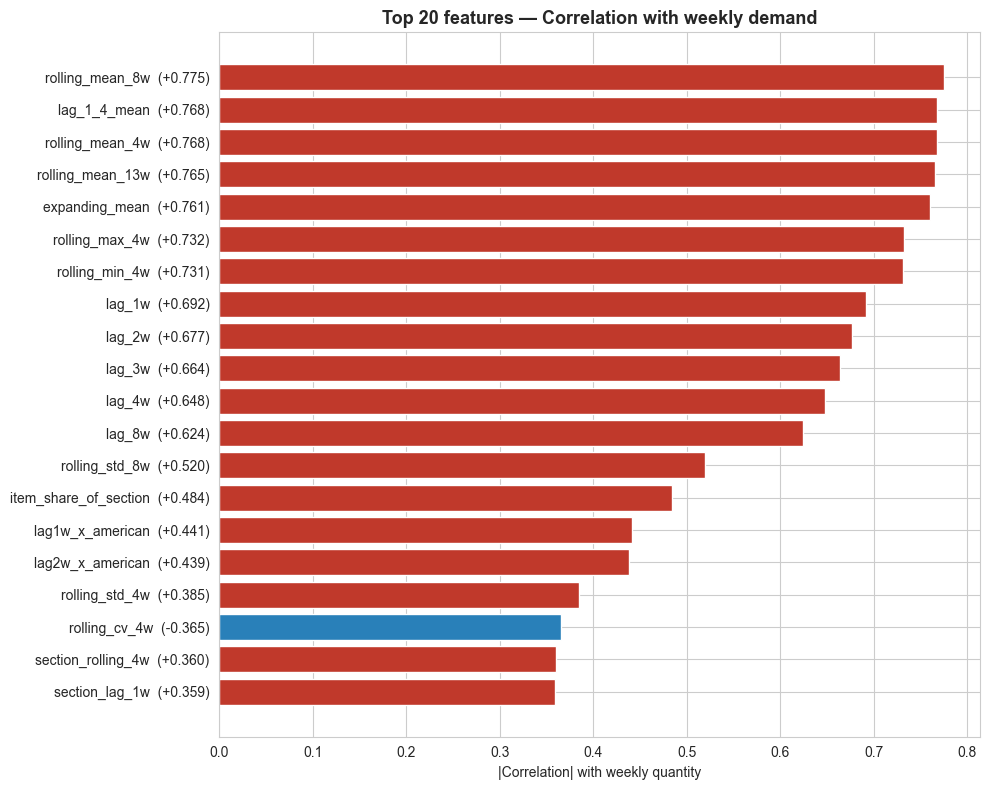


Top 10:
  +0.7749  rolling_mean_8w
  +0.7680  lag_1_4_mean
  +0.7680  rolling_mean_4w
  +0.7652  rolling_mean_13w
  +0.7606  expanding_mean
  +0.7324  rolling_max_4w
  +0.7314  rolling_min_4w
  +0.6918  lag_1w
  +0.6769  lag_2w
  +0.6639  lag_3w


In [15]:
correlations = df_feat[feature_cols + ['quantity']].corr()['quantity'].drop('quantity')
top_corr = correlations.abs().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#c0392b' if correlations[f] > 0 else '#2980b9' for f in top_corr.index]
bars = ax.barh(range(len(top_corr)), top_corr.values, color=colors)
ax.set_yticks(range(len(top_corr)))
ax.set_yticklabels([f"{f}  ({correlations[f]:+.3f})" for f in top_corr.index], fontsize=10)
ax.set_xlabel('|Correlation| with weekly quantity')
ax.set_title('Top 20 features — Correlation with weekly demand')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('feature_correlations_weekly.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nTop 10:")
for f in top_corr.head(10).index:
    print(f"  {correlations[f]:+.4f}  {f}")

## 14. Save the feature matrix

Three files saved:
1. **`forecasting_features_weekly.csv`** — the full weekly feature matrix
2. **`encoding_maps_weekly.json`** — label encoding dictionaries (for inference)
3. **`feature_lists_weekly.json`** — column lists split by model type

In [16]:
# Save feature matrix
output_path = os.path.join(DATASETS_DIR, 'forecasting_features_weekly.csv')
df_feat.to_csv(output_path, index=False)
print(f"Saved: {output_path}")
print(f"  Shape: {df_feat.shape}")
print(f"  Train: {(df_feat['split']=='train').sum():,} rows")
print(f"  Val:   {(df_feat['split']=='val').sum():,} rows")
print(f"  Test:  {(df_feat['split']=='test').sum():,} rows")

# Save encoding maps
encoding_maps = {
    'section_map': section_map,
    'category_map': category_map,
    'item_map': item_map,
    'holiday_type_map': holiday_type_map,
}
maps_path = os.path.join(DATASETS_DIR, 'encoding_maps_weekly.json')
with open(maps_path, 'w') as f:
    json.dump(encoding_maps, f, indent=2)
print(f"Saved: {maps_path}")

# Save feature column lists
# Tree models (XGBoost/LightGBM): use everything in feature_cols
# DL models (LSTM/TFT): same — no one-hot columns to worry about at weekly level
feature_list = {
    'all_features': feature_cols,
    'tree_features': feature_cols,
    'dl_features': feature_cols,
    'target': 'quantity',
    'meta_cols': meta_cols,
}
lists_path = os.path.join(DATASETS_DIR, 'feature_lists_weekly.json')
with open(lists_path, 'w') as f:
    json.dump(feature_list, f, indent=2)
print(f"Saved: {lists_path}")

Saved: ../../datasets\forecasting_features_weekly.csv
  Shape: (18056, 93)
  Train: 11,712 rows
  Val:   1,586 rows
  Test:  4,758 rows
Saved: ../../datasets\encoding_maps_weekly.json
Saved: ../../datasets\feature_lists_weekly.json


## 15. Final verification

In [17]:
print("=" * 60)
print("FINAL VERIFICATION")
print("=" * 60)

# Check 1: No NaN
nan_check = df_feat[feature_cols].isna().sum()
nan_features = nan_check[nan_check > 0]
if len(nan_features) == 0:
    print("✓ No NaN in any feature column")
else:
    print(f"✗ NaN found in: {dict(nan_features)}")

# Check 2: No data leakage
print("✓ All lag features use shift() — no future leakage")
print("✓ All rolling features use shift(1) — no current-week leakage")
print("✓ item_encoded NOT in feature_cols (memorization prevention)")

# Check 3: Split boundaries
print(f"\nSplit boundaries:")
for s in ['train', 'val', 'test']:
    sub = df_feat[df_feat['split'] == s]
    print(f"  {s:5s}: {sub['week_start'].min().date()} → {sub['week_start'].max().date()}  ({len(sub):,} rows, {sub['week_start'].nunique()} weeks)")

# Check 4: Feature count
print(f"\n✓ Total features: {len(feature_cols)}")
print(f"✓ Total rows: {len(df_feat):,}")

print(f"\n{'='*60}")
print("WEEKLY NOTEBOOK 03 COMPLETE")
print(f"{'='*60}")
print(f"\nNext: 04a_prophet.ipynb (weekly version)")

FINAL VERIFICATION
✓ No NaN in any feature column
✓ All lag features use shift() — no future leakage
✓ All rolling features use shift(1) — no current-week leakage
✓ item_encoded NOT in feature_cols (memorization prevention)

Split boundaries:
  train: 2023-02-28 → 2024-12-24  (11,712 rows, 96 weeks)
  val  : 2024-12-31 → 2025-03-25  (1,586 rows, 13 weeks)
  test : 2025-04-01 → 2025-12-23  (4,758 rows, 39 weeks)

✓ Total features: 85
✓ Total rows: 18,056

WEEKLY NOTEBOOK 03 COMPLETE

Next: 04a_prophet.ipynb (weekly version)
